In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys 
sys.path.append('../src')

from cnn import *
from datas import *
from train import *

In [4]:
from torch.utils.data import DataLoader
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
%matplotlib inline

In [5]:
timepoint = '2H'

bigwig_path = '../data/bws_for_predictor/SPT16_4D_2HdTAG_Sox2_S46_1_120_sorted.bw'
pol2_bigwig_path= '../data/Pol2/SPT16_2HdTAG_Pol2.bw'
fasta_path = '../data/GRCm38.primary_assembly.genome.fa'
bed_path = '../data/bed_files/GFP_TTseq_max_sorted_top_quintile.bed'

window_left = 500
window_right = 2000
signal_bins = None
batch_size = 256
epochs = 900
lr = 1e-4
device = 'mps'
weight_decay = 0
patience=20

In [6]:
dataset = SequenceDualBigWigDataset(
    fasta_path=str(fasta_path),
    k4_bigwig_path=str(pol2_bigwig_path),
    target_bigwig_path=str(bigwig_path),
    bed_path=str(bed_path),
    signal_bins=signal_bins,
    window_left=window_left,
    window_right=window_right
)

In [7]:
len(dataset)

3728

### Sanity check

In [21]:
import numpy as np

idx = round(np.random.rand() * len(dataset))
*x, y = dataset[idx]
x[0].shape, x[1].shape, y.shape

(torch.Size([4, 2500]), torch.Size([2500]), torch.Size([2500]))

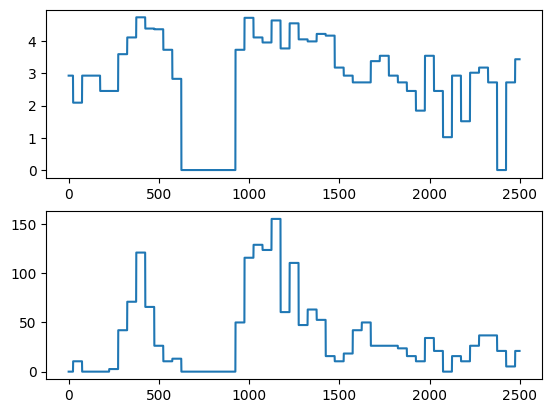

In [22]:
fig, axs = plt.subplots(2, 1)
axs[0].plot(x[1])
axs[1].plot(y)

### Train

8283.734


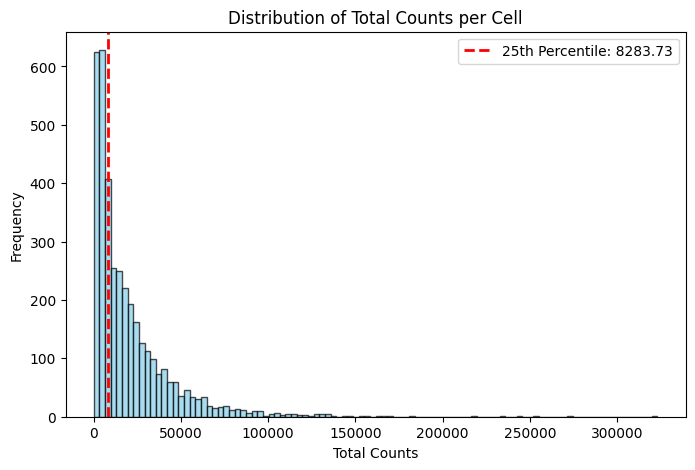

In [23]:
loader = DataLoader(dataset, batch_size=256, num_workers=1, shuffle=False)

tot_counts = []
for _, _, y_batch in loader:
    tot_counts.extend(y_batch.sum(axis=-1).numpy())


config = TrainConfig(
    lr=lr,
    weight_decay=weight_decay,
    epochs=epochs,
    patience=patience,
    device=device
)

cutoff = np.percentile(tot_counts, 40)
print(cutoff)

plt.figure(figsize=(8, 5))
plt.hist(tot_counts, bins=100, color='skyblue', edgecolor='black', alpha=0.7)

plt.axvline(cutoff, color='red', linestyle='--', linewidth=2, label=f'25th Percentile: {cutoff:.2f}')

plt.title("Distribution of Total Counts per Cell")
plt.xlabel("Total Counts")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [24]:
config = TrainConfig(
    lr=lr,
    weight_decay=weight_decay,
    epochs=epochs,
    patience=patience,
    device=device,
    loss_type='bpnet',
    min_profile=cutoff
)

model = train_cnn_regressor(
    dataset=dataset,
    batch_size=batch_size,
    config=config,
)

Epoch 1/900 - train loss: 151707, val loss: 147426
Epoch 2/900 - train loss: 149414, val loss: 145344
Epoch 3/900 - train loss: 149145, val loss: 144227
Epoch 4/900 - train loss: 147917, val loss: 143873
Epoch 5/900 - train loss: 147496, val loss: 143295
Epoch 6/900 - train loss: 147570, val loss: 143202
Epoch 7/900 - train loss: 146446, val loss: 142754
Epoch 8/900 - train loss: 145621, val loss: 142299
Epoch 9/900 - train loss: 145080, val loss: 141823
Epoch 10/900 - train loss: 145583, val loss: 141527
Epoch 11/900 - train loss: 145100, val loss: 141196
Epoch 12/900 - train loss: 144533, val loss: 141029
Epoch 13/900 - train loss: 144914, val loss: 140763
Epoch 14/900 - train loss: 144407, val loss: 140649
Epoch 15/900 - train loss: 144487, val loss: 140397
Epoch 16/900 - train loss: 143962, val loss: 140353
Epoch 17/900 - train loss: 143564, val loss: 140139
Epoch 18/900 - train loss: 143573, val loss: 140058
Epoch 19/900 - train loss: 143797, val loss: 140052
Epoch 20/900 - train 

In [ ]:
import time
from pathlib import Path

date = time.strftime("%Y%m%d")
model_name = f'seqpol2_{timepoint}_{date}'
output_model_path = Path(f'../models/{model_name}.pt')

model.save_model(output_model_path)

In [28]:
model_name

'seqpol2_2H_20260501'

In [ ]:
import os 
os.makedirs('../models/loaders', exist_ok=True)

torch.save(model.val_loader, f'../models/loaders/{model_name}_val.pt')
torch.save(model.test_loader, f'../models/loaders/{model_name}_test.pt')
torch.save(model.train_loader, f'../models/loaders/{model_name}_train.pt')

### Analysis

In [ ]:
import torch 
import os 

model_name = 'seqpol2_2H_20260501'
model = BPNetK4Model.load_model(f'../models/{model_name}.pt')
model.test_loader = torch.load(f'../models/loaders/{model_name}_test.pt', weights_only=False)
model.train_loader = torch.load(f'../models/loaders/{model_name}_train.pt', weights_only=False)
model.val_loader = torch.load(f'../models/loaders/{model_name}_val.pt', weights_only=False)

results_dir = f'../results/{model_name}'
os.makedirs(results_dir, exist_ok=True)

In [10]:
import torch

loaders = {
    'Train': model.train_loader,
    'Validation': model.val_loader,
    'Test': model.test_loader
}

# Get a reference batch for shapes/values
sample_batch = next(iter(model.test_loader))
*x_ref, y_ref = sample_batch

# 1. Permuted Baseline (shuffled inputs)
perm_idx = torch.randperm(x_ref[0].size(0))
perm_x = [x[perm_idx] for x in x_ref]
perm_loader = DataLoader(torch.utils.data.TensorDataset(*perm_x, y_ref), batch_size=32)

# 2. Gaussian Baseline
gauss_x = [torch.randn_like(x) for x in x_ref]
gauss_loader = DataLoader(torch.utils.data.TensorDataset(*gauss_x, y_ref), batch_size=32)

# 3. Uniform Baseline (values between 0 and 1)
unif_x = [torch.rand_like(x) for x in x_ref]
unif_loader = DataLoader(
    torch.utils.data.TensorDataset(*unif_x, y_ref), 
    batch_size=32
)

loaders['Uniform'] = unif_loader
loaders['Permuted'] = perm_loader
loaders['Gaussian'] = gauss_loader

Evaluating Train split...
Evaluating Validation split...


KeyboardInterrupt: 

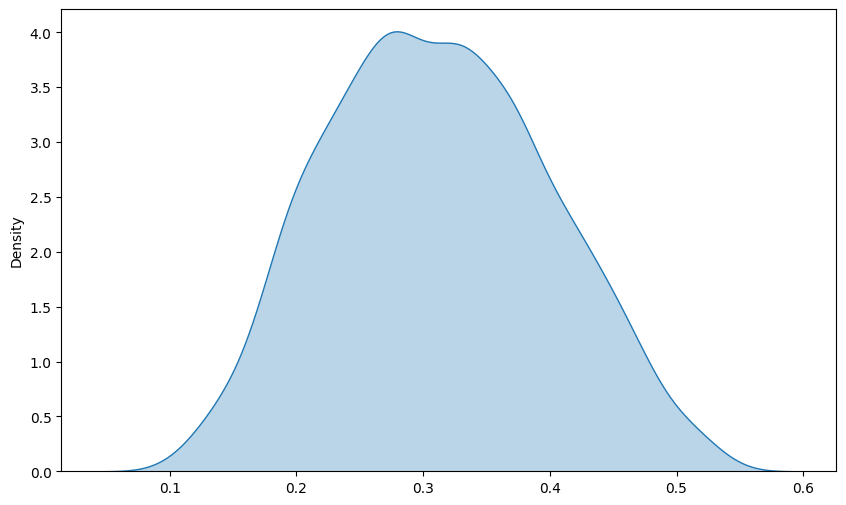

In [11]:
from train import evaluate_model_metrics
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

correlations = []
plt.figure(figsize=(10, 6))

loader_metrics = {}

for split_name, loader in loaders.items():
    if loader is None:
        continue
        
    print(f"Evaluating {split_name} split...")
    metrics = evaluate_model_metrics(
        model, loader, 
        device="mps", 
        min_profile=model.min_profile
    )

    loader_metrics[split_name] = metrics
    
    pcorr, _ = pearsonr(metrics['log_counts_true'], metrics['log_counts_pred'])
    scorr, _ = spearmanr(metrics['log_counts_true'], metrics['log_counts_pred'])

    correlations.append({
        'Split': split_name,
        'Pearson': pcorr,
        'Spearman': scorr
    })
    
    sns.kdeplot(data=metrics['profile_jsd'], label=split_name, fill=True, alpha=0.3)

plt.title('Jensen-Shannon Distance Distribution by Split')
plt.xlabel('Jensen-Shannon Distance')
plt.ylabel('Density')
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

df_corr = pd.DataFrame(correlations)
display(df_corr)



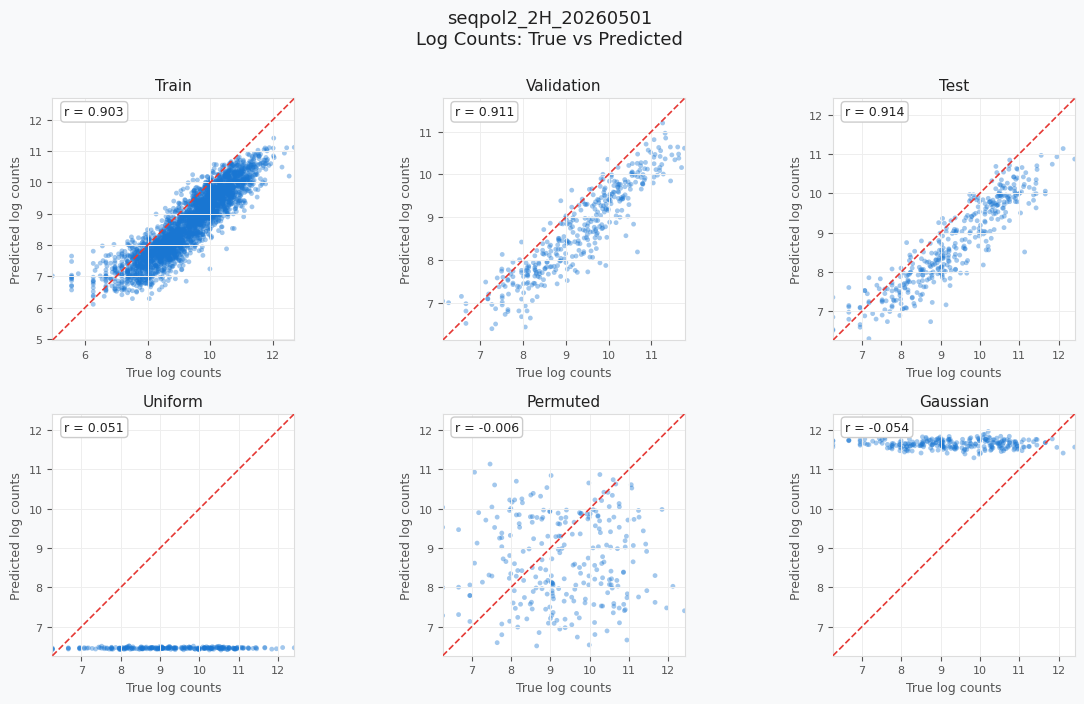

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(12, 7))
fig.patch.set_facecolor('#f8f9fa')
axs = axs.flatten()

for i, (split_name, metrics) in enumerate(loader_metrics.items()):
    ax = axs[i]
    x = np.array(metrics['log_counts_true'])
    y = np.array(metrics['log_counts_pred'])

    ax.scatter(x, y, alpha=0.4, s=12, color='#1976d2', edgecolors='none', rasterized=True)

    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, color='#e53935', lw=1.2, ls='--', zorder=3, label='y = x')

    r, _ = pearsonr(x, y)
    ax.text(0.05, 0.93, f'r = {r:.3f}', transform=ax.transAxes,
            fontsize=9, color='#212121',
            bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='round,pad=0.3'))

    ax.set_facecolor('#ffffff')
    ax.set_title(split_name, fontsize=11, color='#212121', pad=6)
    ax.set_xlabel('True log counts', fontsize=9, color='#555555')
    ax.set_ylabel('Predicted log counts', fontsize=9, color='#555555')
    ax.tick_params(colors='#555555', labelsize=8)
    for spine in ax.spines.values():
        spine.set_color('#dddddd')
    ax.grid(True, color='#eeeeee', lw=0.7, zorder=0)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_aspect('equal')

for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

fig.suptitle(f'{model_name}\nLog Counts: True vs Predicted', fontsize=13,
             color='#212121', y=1)
plt.tight_layout()
plt.savefig(f'{results_dir}/counts_correlation.png')
plt.show()


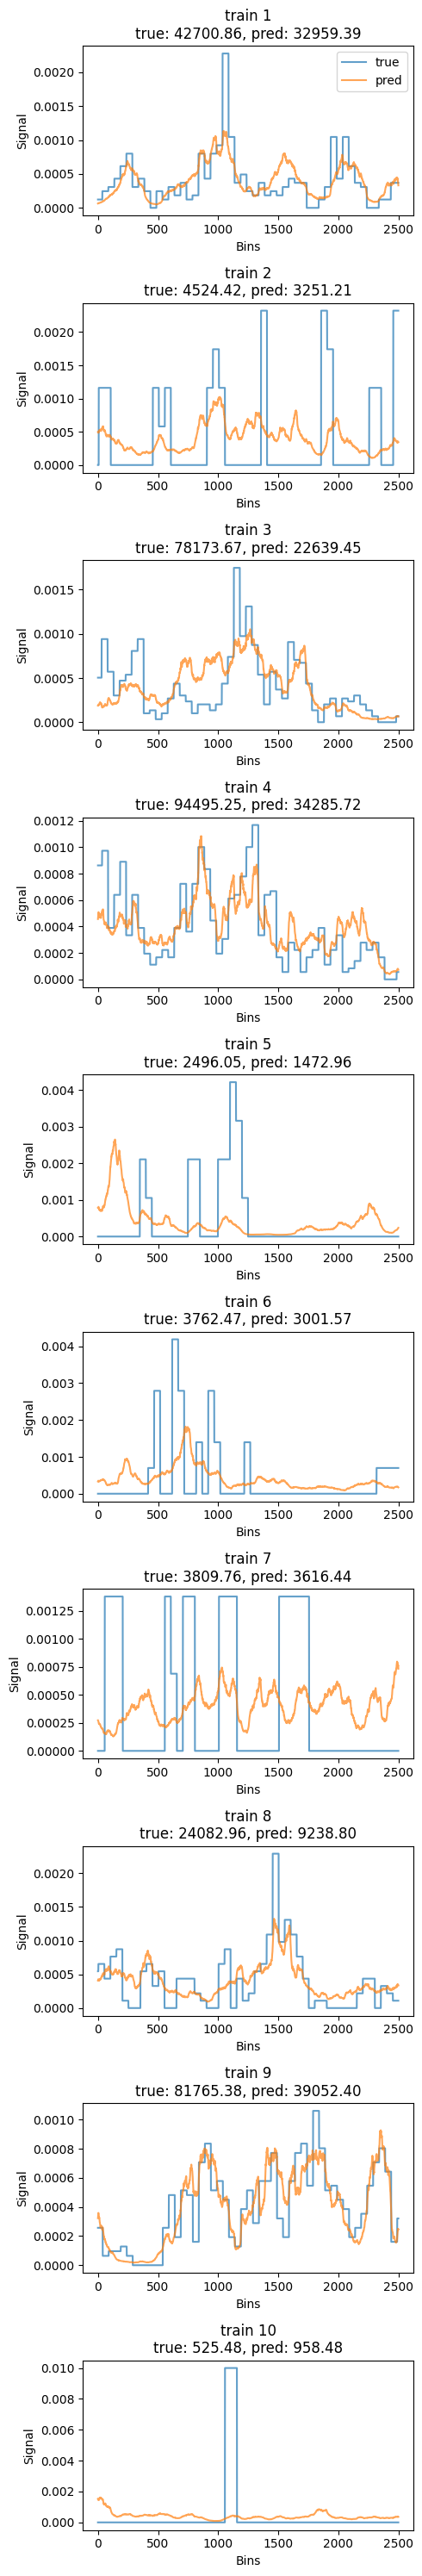

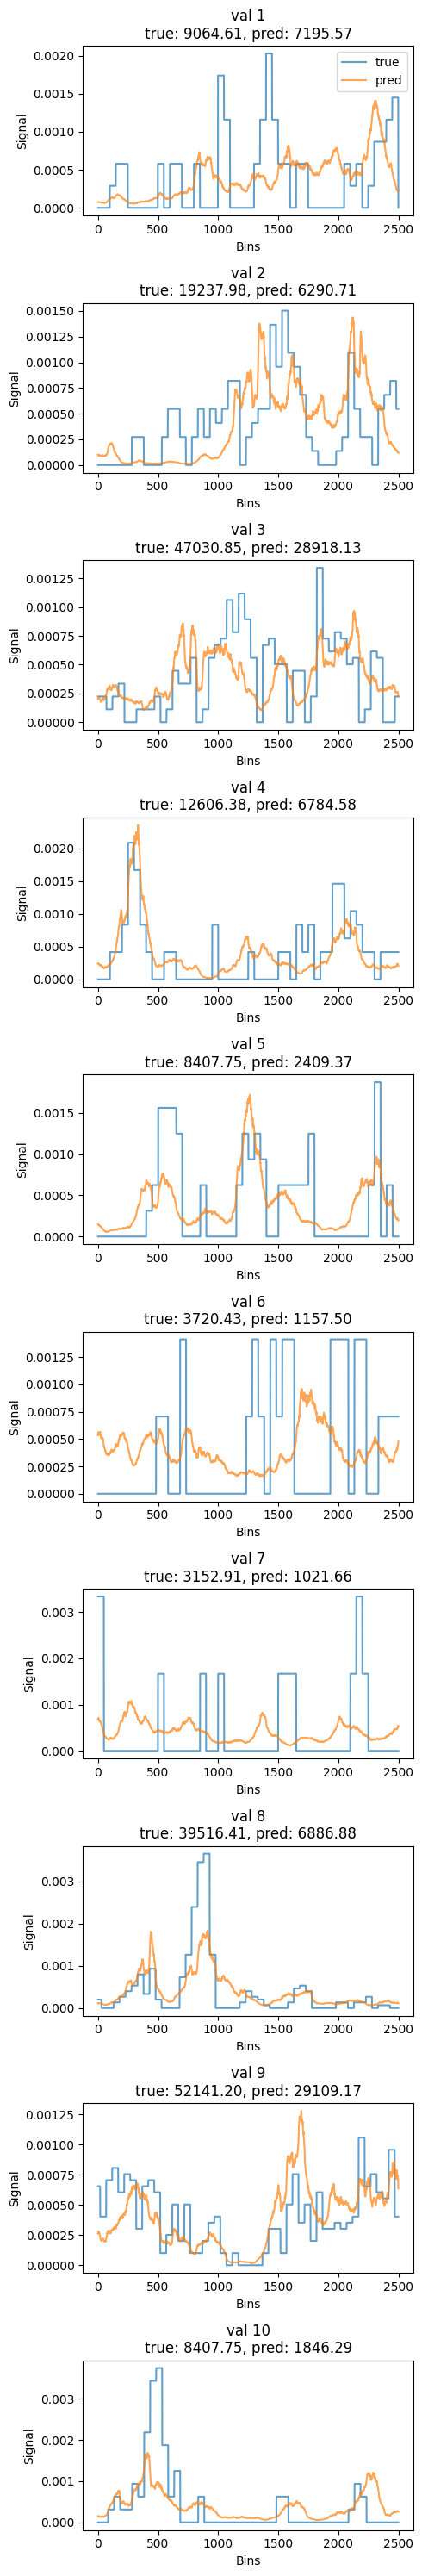

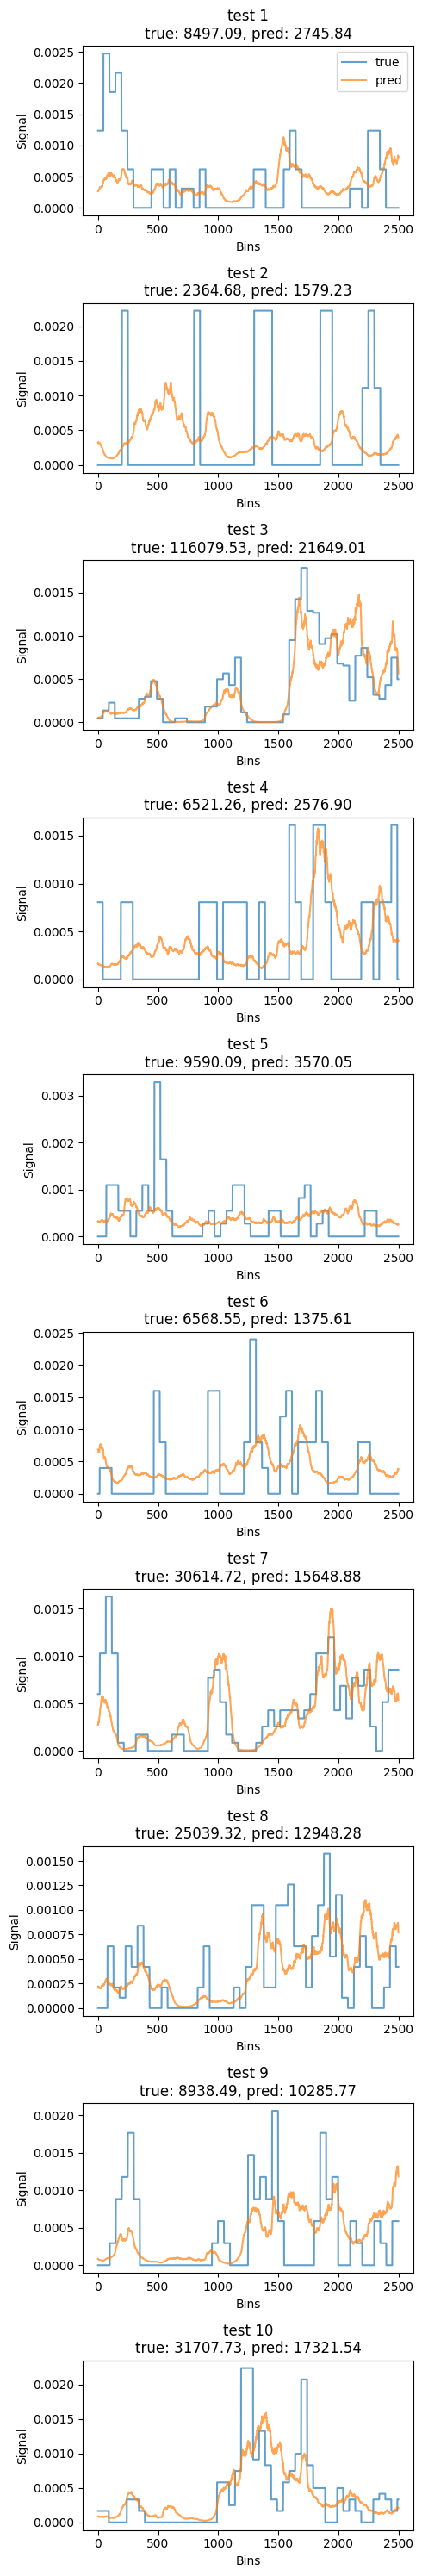

In [ ]:
visualize_split_predictions(
    model,
    device='cpu',
    n_examples_per_split=10,
)

### Track motifs

In [12]:
import os
import torch

os.environ['NUMBA_NUM_THREADS'] = '1'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

if torch.backends.mps.is_available():
    torch.mps.empty_cache()
    

/opt/anaconda3/envs/mocha/lib/python3.12/site-packages/captum/attr/_core/deep_lift.py:296: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/opt/anaconda3/envs/mocha/lib/python3.12/site-packages/captum/attr/_core/deep_lift.py:296: UserWarning: Input Tensor 1 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/opt/anaconda3/envs/mocha/lib/python3.12/site-packages/captum/log/dummy_log.py:54: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


Collected 374 sequences with counts >= 10 using deeplift on counts head
Running TF-MoDISco on 374 seqs, L=2500, window_size=21...
Using 2299 positive seqlets
Found 6 positive, 0 negative motif patterns
Saved MoDISco results to ../results/seqpol2_2H_20260501/modisco_counts.h5


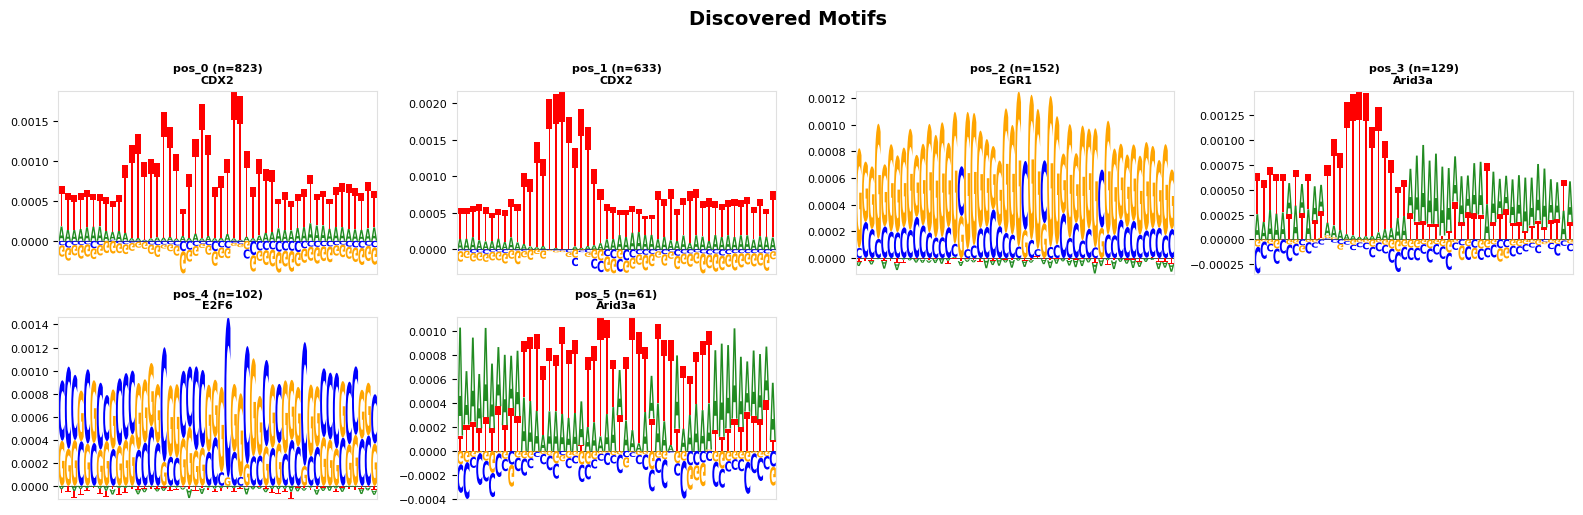

Motif           Seqlets  JASPAR hit                    r
────────────────────────────────────────────────────────
pos_0               823  CDX2                      0.764
pos_1               633  CDX2                      0.765
pos_2               152  EGR1                      0.812
pos_3               129  Arid3a                    0.744
pos_4               102  E2F6                      0.704
pos_5                61  Arid3a                    0.810
Saved MotifTracker to ../results/seqpol2_2H_20260501/tracker_counts.pkl  (re-attach model after loading)


In [18]:
from motif_track import MotifTracker
from channel_track import ChannelTracker

# ── Motif discovery ─────────────────────────────────
tracker = MotifTracker(model, device='mps')
tracker.run(
    model.test_loader,
    # min_counts=model.min_profile,
    min_counts=10,
    method='deeplift',
    head='counts',
    save_path=f'{results_dir}/modisco_counts.h5'
)
tracker.match_jaspar(db_path='../data/JASPAR2024_CORE_vertebrates.txt')

fig = tracker.plot_motifs()
fig.savefig(f'{results_dir}/motifs_counts.png')

tracker.summary()
tracker.save(f'{results_dir}/tracker_counts.pkl')

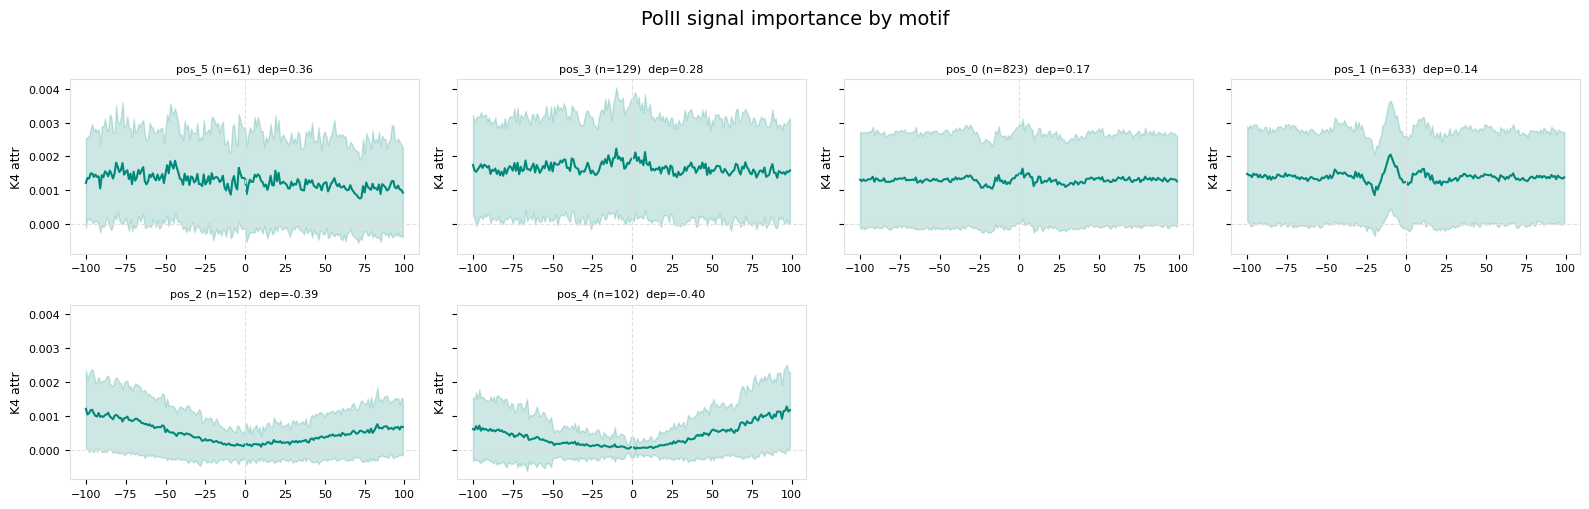

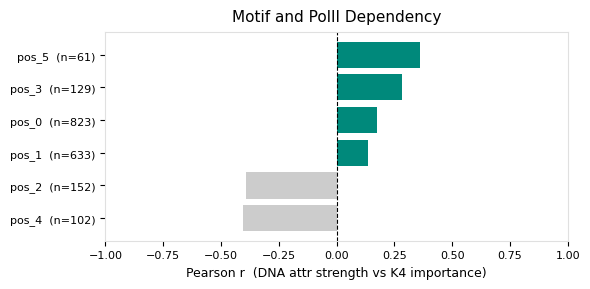

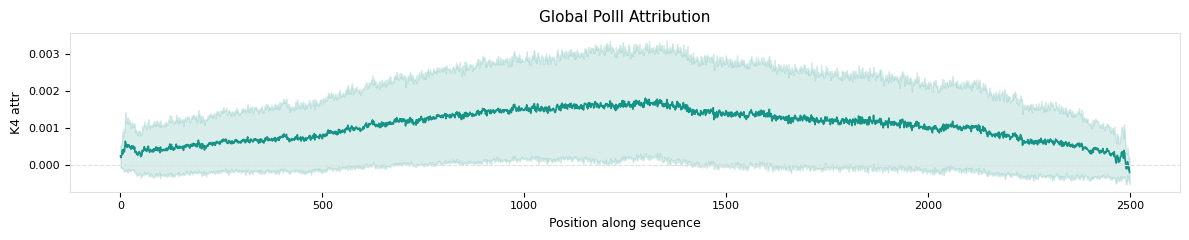

In [19]:
# ── Pol2 channel analysis ──────────
ch = ChannelTracker(tracker, k4_window=200)
ch.compute_k4_profiles()
ch.compute_joint_analysis()
ch.compute_k4_dependency()
ch.compute_global_k4()

k4_profiles = ch.plot_k4_profiles(title='PolII signal importance by motif')              # which motifs show K4 enrichment
k4_profiles.savefig(f'{results_dir}/pol2_counts.png')
k4_profiles = ch.plot_k4_dependency(title='Motif and PolII Dependency')  
k4_profiles.savefig(f'{results_dir}/pol2_counts_dependency.png')
k4_profiles = ch.plot_global_k4(title='Global PolII Attribution')                # global K4 baseline
k4_profiles.savefig(f'{results_dir}/pol2_counts_global.png')


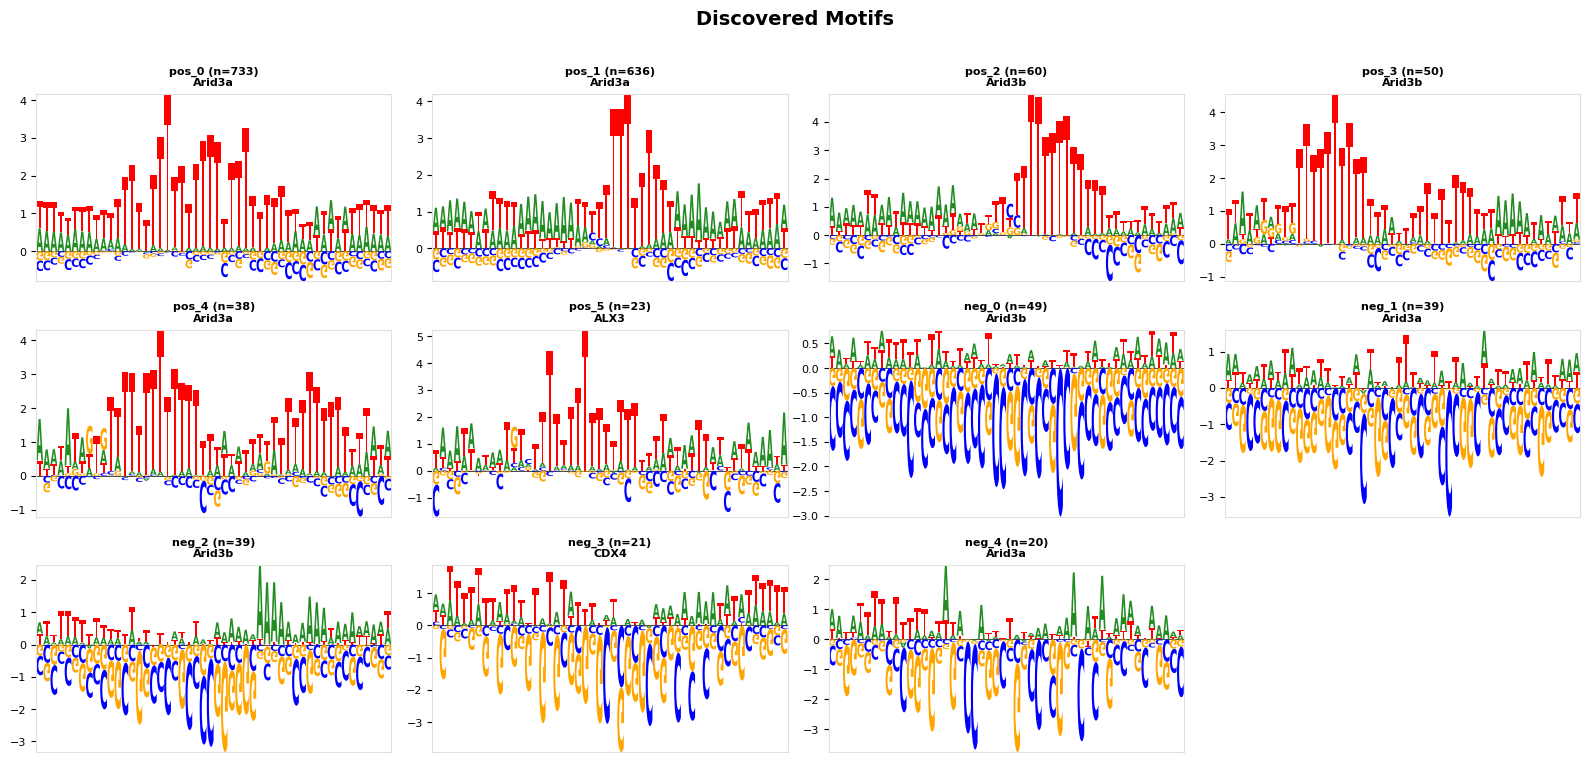

Motif           Seqlets  JASPAR hit                    r
────────────────────────────────────────────────────────
pos_0               733  Arid3a                    0.728
pos_1               636  Arid3a                    0.719
pos_2                60  Arid3b                    0.715
pos_3                50  Arid3b                    0.803
pos_4                38  Arid3a                    0.722
pos_5                23  ALX3                      0.783
neg_0                49  Arid3b                    0.660
neg_1                39  Arid3a                    0.703
neg_2                39  Arid3b                    0.668
neg_3                21  CDX4                      0.680
neg_4                20  Arid3a                    0.669
Saved MotifTracker to ../results/seqpol2_2H_20260501/tracker_profile.pkl  (re-attach model after loading)


In [ ]:
from motif_track import MotifTracker
from channel_track import ChannelTracker

# ── Motif discovery ─────────────────────────────────
tracker = MotifTracker(model, device='mps')
tracker.run(
    model.test_loader,
    min_counts=model.min_profile,
    method='deeplift',
    head='profile',
    save_path=f'{results_dir}/modisco_profile.h5'
)
tracker.match_jaspar(db_path='../data/JASPAR2024_CORE_vertebrates.txt')

fig = tracker.plot_motifs()
fig.savefig(f'{results_dir}/motifs_profile.png')

tracker.summary()
tracker.save(f'{results_dir}/tracker_profile.pkl')

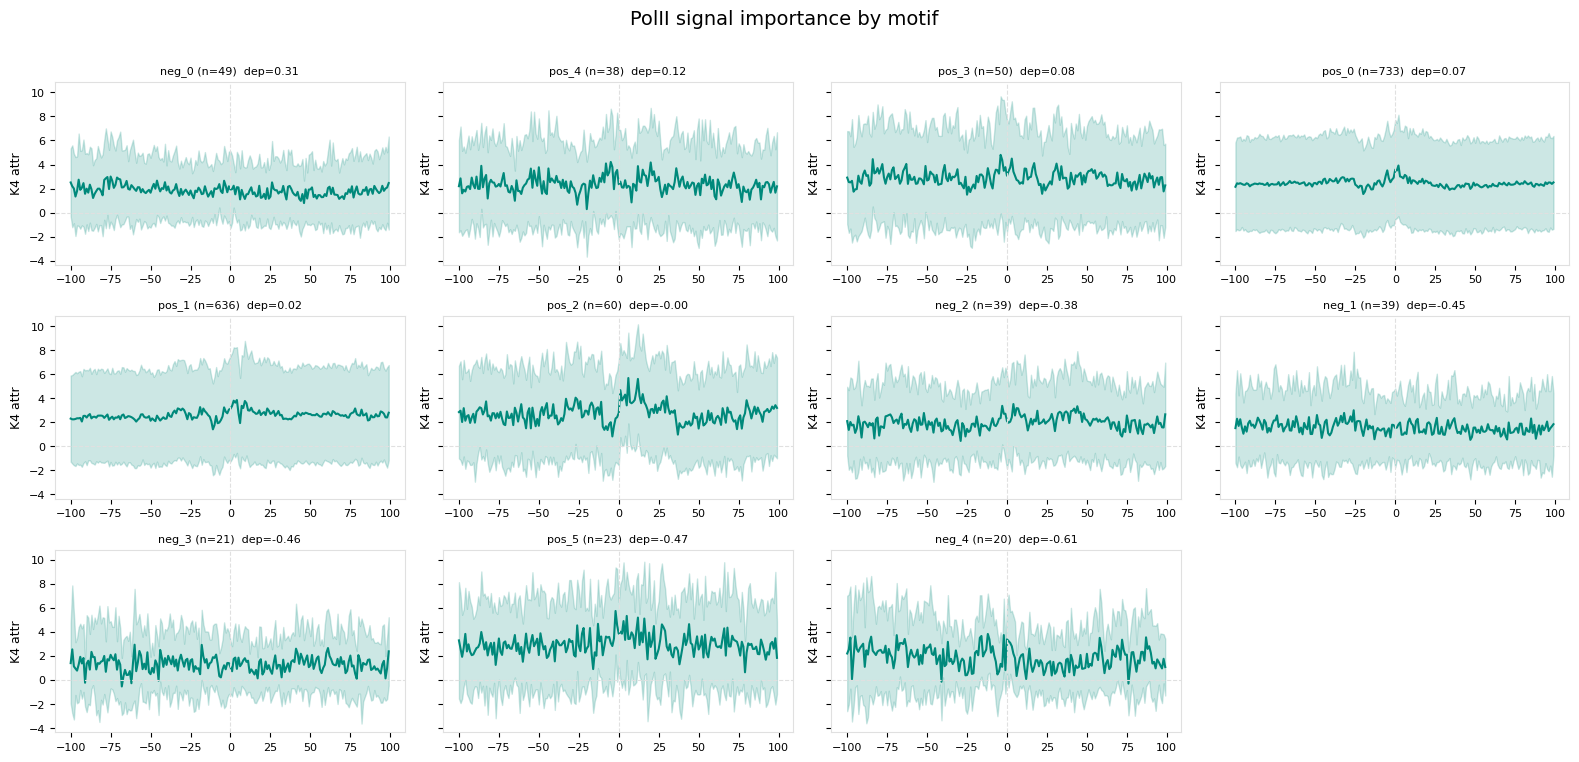

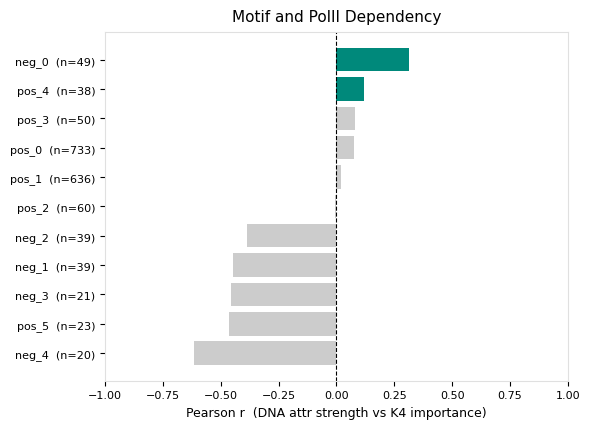

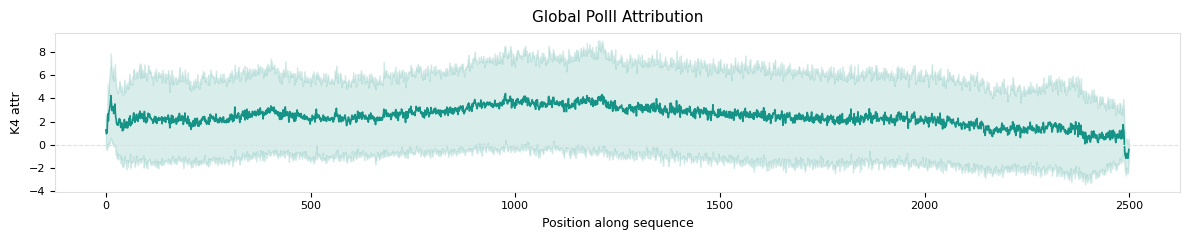

In [ ]:
# ── Pol2 channel analysis ──────────
ch = ChannelTracker(tracker, k4_window=200)
ch.compute_k4_profiles()
ch.compute_joint_analysis()
ch.compute_k4_dependency()
ch.compute_global_k4()

k4_profiles = ch.plot_k4_profiles(title='PolII signal importance by motif')              # which motifs show K4 enrichment
k4_profiles.savefig(f'{results_dir}/pol2_profiles.png')
k4_profiles = ch.plot_k4_dependency(title='Motif and PolII Dependency')  
k4_profiles.savefig(f'{results_dir}/pol2_profile_dependency.png')
k4_profiles = ch.plot_global_k4(title='Global PolII Attribution')                # global K4 baseline
k4_profiles.savefig(f'{results_dir}/pol2_profile_global.png')
